Import thư viện và load dữ liệu

In [1]:
!pip install rdkit-pypi imbalanced-learn pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện Hóa tin học RDKit
from rdkit import Chem
from rdkit.Chem import MACCSkeys
from rdkit.Chem import Draw

# Thư viện Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print("Đã import thành công các thư viện cho dự án Drug Discovery!")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Đã import thành công các thư viện cho dự án Drug Discovery!


In [5]:
df = pd.read_csv('tox21.csv')

# Hiển thị 5 dòng đầu tiên
display(df.head())

# Hiển thị thông tin tổng quan để xem có bao nhiêu cột numeric, bao nhiêu cột object
print("\nThông tin bộ dữ liệu:")
df.info()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O



Thông tin bộ dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7831 entries, 0 to 7830
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   NR-AR          7265 non-null   float64
 1   NR-AR-LBD      6758 non-null   float64
 2   NR-AhR         6549 non-null   float64
 3   NR-Aromatase   5821 non-null   float64
 4   NR-ER          6193 non-null   float64
 5   NR-ER-LBD      6955 non-null   float64
 6   NR-PPAR-gamma  6450 non-null   float64
 7   SR-ARE         5832 non-null   float64
 8   SR-ATAD5       7072 non-null   float64
 9   SR-HSE         6467 non-null   float64
 10  SR-MMP         5810 non-null   float64
 11  SR-p53         6774 non-null   float64
 12  mol_id         7831 non-null   object 
 13  smiles         7831 non-null   object 
dtypes: float64(12), object(2)
memory usage: 856.6+ KB


EDA


[1] KIỂM TRA DỮ LIỆU KHUYẾT THIẾU:
smiles       0
SR-p53    1057

[2] KIỂM TRA DỮ LIỆU TRÙNG LẶP:
Số lượng cấu trúc SMILES bị lặp lại trong tập dữ liệu: 0

[3] KIỂM TRA DỮ LIỆU BẤT ĐỒNG NHẤT (INCONSISTENCY):
Không phát hiện cấu trúc SMILES nào có nhãn mâu thuẫn.

[4] PHÂN TÍCH PHÂN PHỐI NHÃN (CLASS DISTRIBUTION):


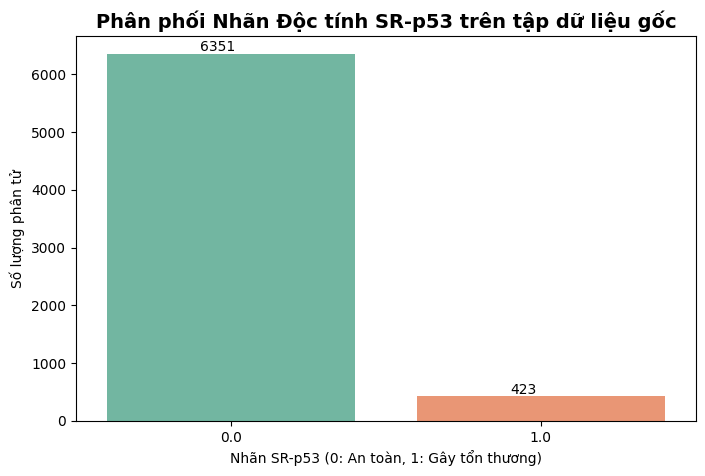

-> Tổng số phân tử có nhãn hợp lệ: 6774
-> Tỷ lệ chất gây độc (Nhãn 1): 6.24%
=> Dữ liệu bị mất cân bằng nghiêm trọng.


In [12]:
# 1. Kiểm tra dữ liệu khuyết thiếu (Missing Values)
print("\n[1] KIỂM TRA DỮ LIỆU KHUYẾT THIẾU:")
missing_data = df[['smiles', 'SR-p53']].isnull().sum()
print(missing_data.to_string())

# 2. Kiểm tra dữ liệu trùng lặp (Duplicates)
print("\n[2] KIỂM TRA DỮ LIỆU TRÙNG LẶP:")
duplicate_smiles = df.duplicated(subset=['smiles']).sum()
print(f"Số lượng cấu trúc SMILES bị lặp lại trong tập dữ liệu: {duplicate_smiles}")

# 3. Kiểm tra dữ liệu bất nhất (Inconsistent Data)
# Dữ liệu bất nhất là khi cùng 1 cấu trúc SMILES nhưng lại mang nhãn SR-p53 khác nhau (Vừa 0 vừa 1)
print("\n[3] KIỂM TRA DỮ LIỆU BẤT ĐỒNG NHẤT (INCONSISTENCY):")
# Tạm loại bỏ các dòng Null để kiểm tra tính logic của các dòng có dữ liệu
df_valid = df.dropna(subset=['SR-p53'])
# Đếm số lượng nhãn độc nhất (unique) cho mỗi SMILES
smiles_nunique_labels = df_valid.groupby('smiles')['SR-p53'].nunique()
inconsistent_count = (smiles_nunique_labels > 1).sum()

if inconsistent_count > 0:
    print(f"Phát hiện {inconsistent_count} cấu trúc SMILES có nhãn mâu thuẫn (vừa Độc vừa An toàn).")
else:
    print(f"Không phát hiện cấu trúc SMILES nào có nhãn mâu thuẫn.")

# 4. Phân tích phân phối lớp (Class Imbalance)
print("\n[4] PHÂN TÍCH PHÂN PHỐI NHÃN (CLASS DISTRIBUTION):")
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='SR-p53', data=df, palette='Set2')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 50))

plt.title('Phân phối Nhãn Độc tính SR-p53 trên tập dữ liệu gốc', fontsize=14, fontweight='bold')
plt.xlabel('Nhãn SR-p53 (0: An toàn, 1: Gây tổn thương)')
plt.ylabel('Số lượng phân tử')
plt.show()

toxic_count = df['SR-p53'].sum()
valid_count = df['SR-p53'].notna().sum()
print(f"-> Tổng số phân tử có nhãn hợp lệ: {valid_count}")
print(f"-> Tỷ lệ chất gây độc (Nhãn 1): {(toxic_count/valid_count)*100:.2f}%")
print("=> Dữ liệu bị mất cân bằng nghiêm trọng.")

Tiền xử lý - Trích xuất đặc trưng (SMILES to MACCS Keys)

In [13]:
print("Đang dịch mã chuỗi SMILES thành đồ thị và trích xuất MACCS Keys (Subgraph patterns)...")

# 1. Hàm chuyển đổi 1 chuỗi đồ thị phân tử thành vector 167 bits (mỗi bit đại diện cho 1 mảnh đồ thị con)
def smiles_to_maccs(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            return list(MACCSkeys.GenMACCSKeys(mol))
        else:
            return None
    except:
        return None

# 2. Tạo bản sao từ DataFrame gốc để làm sạch dữ liệu mà không ảnh hưởng đến bản gốc
df_clean = df.copy()

# 3. Lọc bỏ các giá trị NaN ở cột mục tiêu
df_clean.dropna(subset=['SR-p53'], inplace=True)

# 4. Áp dụng hàm trích xuất Subgraph
df_clean['MACCS'] = df_clean['smiles'].apply(smiles_to_maccs)

# Loại bỏ những dòng bị lỗi không thể vẽ thành đồ thị
df_clean = df_clean.dropna(subset=['MACCS'])

# 5. Tách Features (X) và Target (y)
# Cắt mảng [:, 1:] để bỏ bit index 0 (bit giả)
X = np.array(df_clean['MACCS'].tolist())[:, 1:] 
y = df_clean['SR-p53'].values

print(f"-> Khai thác Subgraph hoàn tất! Ma trận Features (X) có kích thước: {X.shape}")

[15:50:02] WARNING: not removing hydrogen atom without neighbors


-> Ma trận đặc trưng X có kích thước: (6774, 166)


Chia tập dữ liệu (90:10) & Cân bằng lớp bằng SMOTE

In [14]:
# Tỷ lệ 9:1 để tối đa hóa lượng mẫu cho SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)

print(f"Trước khi SMOTE - Số lượng mẫu Train: {len(y_train)} (Nhãn 1: {sum(y_train)})")

# Dùng SMOTE nội suy thêm mẫu đồ thị cho lớp thiểu số (Gây độc)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Sau khi SMOTE   - Số lượng mẫu Train: {len(y_train_resampled)} (Nhãn 1: {sum(y_train_resampled)})")
print(f"Kích thước tập Test để đánh giá thực tế: {len(y_test)}")

Trước khi SMOTE - Số lượng mẫu Train: 6096 (Nhãn 1: 381.0)
Sau khi SMOTE   - Số lượng mẫu Train: 11430 (Nhãn 1: 5715.0)
Kích thước tập Test để đánh giá thực tế: 678


Huấn luyện mô hình Random Forest trên dữ liệu Subgraphs

--- ĐANG HUẤN LUYỆN MÔ HÌNH RANDOM FOREST ---

[BÁO CÁO ĐÁNH GIÁ MÔ HÌNH PHÂN LỚP ĐỒ THỊ]


,precision,recall,f1-score,support
An Toàn (0),0.95,0.92,0.93,636
Độc (1),0.20,0.31,0.24,42
accuracy,,,0.88,0
macro avg,0.57,0.61,0.59,678
weighted avg,0.91,0.88,0.89,678


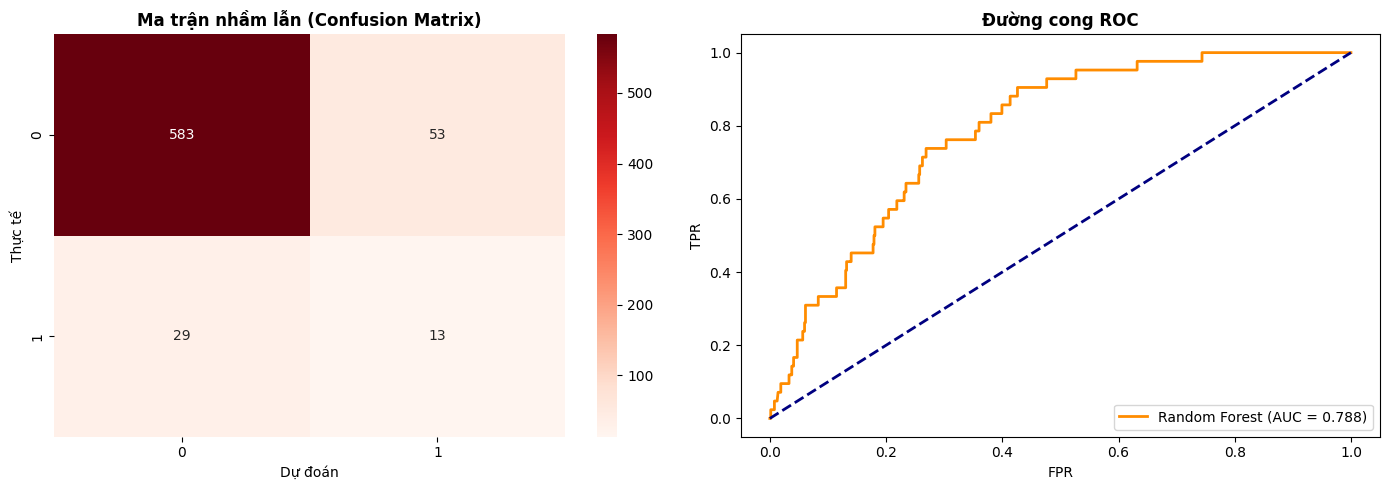

In [36]:
# Cell 6: Huấn luyện mô hình Random Forest trên dữ liệu Subgraphs
print("--- ĐANG HUẤN LUYỆN MÔ HÌNH RANDOM FOREST ---")

rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_resampled, y_train_resampled)

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("\n[BÁO CÁO ĐÁNH GIÁ MÔ HÌNH PHÂN LỚP ĐỒ THỊ]")

report_dict = classification_report(y_test, y_pred, target_names=['An Toàn (0)', 'Độc (1)'], output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

df_report.loc['accuracy', ['precision', 'recall']] = np.nan

formatted_report = df_report.copy()
for col in ['precision', 'recall', 'f1-score']:
    formatted_report[col] = formatted_report[col].apply(lambda x: f"{x:.2f}" if pd.notnull(x) else "")
formatted_report['support'] = formatted_report['support'].apply(lambda x: f"{int(x)}")

display(formatted_report)

# Trực quan hóa kết quả
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Ma trận nhầm lẫn
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', ax=axes[0])
axes[0].set_title('Ma trận nhầm lẫn (Confusion Matrix)', fontweight='bold')
axes[0].set_xlabel('Dự đoán')
axes[0].set_ylabel('Thực tế')

# 2. Đường cong ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest (AUC = {auc(fpr, tpr):.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('Đường cong ROC', fontweight='bold')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

Khám phá các mẫu đồ thị con phân biệt (Discriminative Subgraph Patterns / Toxicophores)

In [29]:
# Lấy trọng số quan trọng của 166 mẫu đồ thị từ Cây quyết định
importances = rf_model.feature_importances_
top_indices = np.argsort(importances)[::-1][:5]

print("BÁO CÁO: TOP 5 MẪU ĐỒ THỊ CON (SUBGRAPH PATTERNS) GÂY ĐỘC TÍNH P53")

top_subgraphs_data = []

for i, idx in enumerate(top_indices):
    # Cộng 1 vì MACCS keys thực tế chạy từ 1 đến 167
    key_num = idx + 1 
    importance_score = importances[idx] * 100
    
    # Lưu từng dòng kết quả vào danh sách
    top_subgraphs_data.append({
        'Hạng': i + 1,
        'Mảnh cấu trúc (Subgraph Pattern)': f"MACCS Key #{key_num}",
        'Mức độ phân biệt (%)': round(importance_score, 2)
    })

# Tạo DataFrame
df_top_subgraphs = pd.DataFrame(top_subgraphs_data)

# Hiển thị bảng
display(df_top_subgraphs.style.hide(axis='index'))

print("\n=> KẾT LUẬN:")
print("Hệ thống Khai thác Đồ thị đã tìm ra được các cấu trúc con (Discriminative Subgraphs) mang tính quyết định.")
print("Sự xuất hiện của các mảnh cấu trúc này có tương quan rất mạnh với khả năng gây tổn thương DNA của phân tử.")

BÁO CÁO: TOP 5 MẪU ĐỒ THỊ CON (SUBGRAPH PATTERNS) GÂY ĐỘC TÍNH P53


Hạng,Mảnh cấu trúc (Subgraph Pattern),Mức độ phân biệt (%)
1,MACCS Key #160,3.780000
2,MACCS Key #145,2.670000
3,MACCS Key #149,2.510000
4,MACCS Key #115,1.930000
5,MACCS Key #105,1.860000



=> KẾT LUẬN:
Hệ thống Khai thác Đồ thị đã tìm ra được các cấu trúc con (Discriminative Subgraphs) mang tính quyết định.
Sự xuất hiện của các mảnh cấu trúc này có tương quan rất mạnh với khả năng gây tổn thương DNA của phân tử.
